In [1]:
#Exploration Uebung mit Fahrradfahrer:innen

In [2]:
import pandas as pd
import matplotlib
%matplotlib inline

In [1]:
!pwd #mit ausrufezeichen ist ein shell befehl, wo ich mein Pfad check

/Users/maryammirza/PycharmProjects/pedestrian_forecast_datascience/src


In [2]:
df = pd.read_csv('../data/bzm_telraam_9000006244.csv) #pd.read_csv() gibt ein DataFrame zurück

SyntaxError: unterminated string literal (detected at line 1) (706934406.py, line 1)

In [5]:
#die ersten 5 zeilen anschauen
df.head()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,heavy_total,v85,car_speed0,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70
0,100033037,2015-07-01 00:00,1.0,NaN,NaN,NaN,0,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100033037,2015-07-01 01:00,1.0,NaN,NaN,NaN,2,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100033037,2015-07-01 02:00,1.0,NaN,NaN,NaN,0,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100033037,2015-07-01 03:00,1.0,NaN,NaN,NaN,0,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100033037,2015-07-01 04:00,1.0,NaN,NaN,NaN,8,NaN,8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#Wie viele zeilen und spalten hat der Datensatz?
df.shape
#Ergebnis: 65777 Zeilen, 24 Spalten

(65777, 24)

In [7]:
#describe gibt mir statistische übersicht über numerische spalten (geht nicht für strings, nan)
df.describe()

,segment_id,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,car_rgt,...,heavy_total,v85,car_speed0,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70
count,65777.0,65777.0,0.0,0.0,0.0,65777.000000,0.0,65777.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,100033037.0,1.0,NaN,NaN,NaN,21.218344,NaN,21.218344,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.0,0.0,NaN,NaN,NaN,25.232305,NaN,25.232305,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,100033037.0,1.0,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,100033037.0,1.0,NaN,NaN,NaN,2.000000,NaN,2.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,100033037.0,1.0,NaN,NaN,NaN,12.000000,NaN,12.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,100033037.0,1.0,NaN,NaN,NaN,33.000000,NaN,33.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,100033037.0,1.0,NaN,NaN,NaN,553.000000,NaN,553.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Anzahl der fehlenden Werte in jeder Spalte:
df.isna().sum() # isna steht für missing values

segment_id         0
date_local         0
uptime             0
ped_lft        65777
ped_rgt        65777
ped_total      65777
bike_lft           0
bike_rgt       65777
bike_total         0
car_lft        65777
car_rgt        65777
car_total      65777
heavy_lft      65777
heavy_rgt      65777
heavy_total    65777
v85            65777
car_speed0     65777
car_speed10    65777
car_speed20    65777
car_speed30    65777
car_speed40    65777
car_speed50    65777
car_speed60    65777
car_speed70    65777
dtype: int64

In [9]:
#Es gibt in ped_lft, ped_rgt, ped_total, bike_rgt, car_lft 65777 fehlende Werte

In [10]:
#Prozent der fehlenden Werte in jeder Spalte:
df.isna().mean()
#1 steht für 100 Prozent, da wo 1.0 steht = fehlen alle Werte
# und wo 0.0 steht = keine Werte fehlen.

segment_id     0.0
date_local     0.0
uptime         0.0
ped_lft        1.0
ped_rgt        1.0
ped_total      1.0
bike_lft       0.0
bike_rgt       1.0
bike_total     0.0
car_lft        1.0
car_rgt        1.0
car_total      1.0
heavy_lft      1.0
heavy_rgt      1.0
heavy_total    1.0
v85            1.0
car_speed0     1.0
car_speed10    1.0
car_speed20    1.0
car_speed30    1.0
car_speed40    1.0
car_speed50    1.0
car_speed60    1.0
car_speed70    1.0
dtype: float64

In [11]:
bike = df[["segment_id", "date_local", "uptime", "bike_lft", "bike_total"]].copy() #df[] heißt spalten auswählen, dann schreib ich nur ein string rein. Wenn ich mehrere will dann mache ich mit [[]] eine Liste und dann da die Strings rein.
#Mit copy erstelle ich eine Kopie. Wenn ich jz bike verändere wird nur bike verändert und nicht auch noch df.

In [12]:
bike #hiermit gibts auch ne Übersicht

,segment_id,date_local,uptime,bike_lft,bike_total
0,100033037,2015-07-01 00:00,1.0,0,0
1,100033037,2015-07-01 01:00,1.0,2,2
2,100033037,2015-07-01 02:00,1.0,0,0
3,100033037,2015-07-01 03:00,1.0,0,0
4,100033037,2015-07-01 04:00,1.0,8,8
...,...,...,...,...,...
65772,100033037,2022-12-31 19:00,1.0,15,15
65773,100033037,2022-12-31 20:00,1.0,3,3
65774,100033037,2022-12-31 21:00,1.0,2,2
65775,100033037,2022-12-31 22:00,1.0,7,7


In [13]:
#Habe rausgefunden das segment_id und uptime dass die immer die gleichen Werte haben, also bei segment_id ist es immer die gleiche id.Bei uptime ist es immer 1.0. Deswegen können die beiden Spalten gelöscht werden weil die bringen nichts.

In [14]:
#Aus bike will ich die 2 Spalten segment_id und uptime lösch

In [15]:
#drop verändert nicht direkt den dataphrame sondern gibt einen neuen zurück wo die beiden spalten gelöscht sind.
bike = bike.drop(columns= ["segment_id", "uptime"]) # kann Spalten und Zeilen löschen, deswegen muss explizit gesagt werden das Spalten gelöscht werden. Mit dem bike = wird es gespeichert

In [16]:
bike

,date_local,bike_lft,bike_total
0,2015-07-01 00:00,0,0
1,2015-07-01 01:00,2,2
2,2015-07-01 02:00,0,0
3,2015-07-01 03:00,0,0
4,2015-07-01 04:00,8,8
...,...,...,...
65772,2022-12-31 19:00,15,15
65773,2022-12-31 20:00,3,3
65774,2022-12-31 21:00,2,2
65775,2022-12-31 22:00,7,7


In [17]:
#Maximum von date_local Spalte
bike["date_local"].max()

'2022-12-31 23:00'

In [18]:
#Min von date_local Spalte
bike["date_local"].min()

'2015-07-01 00:00'

<Axes: >

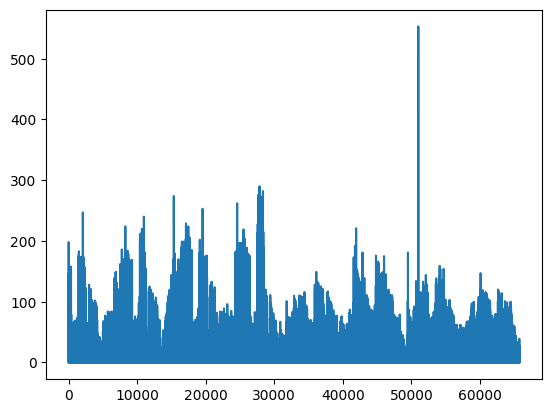

In [19]:
#Plot
bike["bike_lft"].plot()

<Axes: >

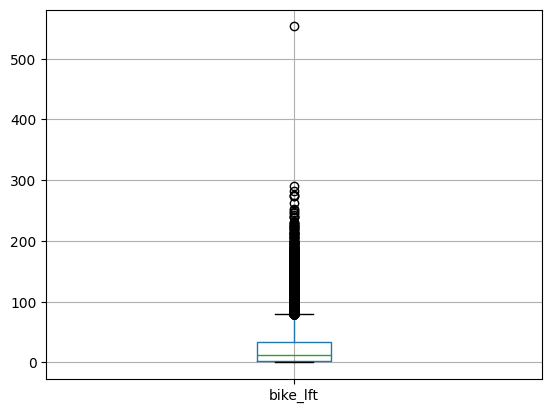

In [20]:
bike.boxplot(column="bike_lft") # hiermit ein boxplot erstellt. Die Verteilung ist sehr schief und unsymmetrisch.
#Es gibt viele Ausreißer.

<Axes: xlabel='date_local'>

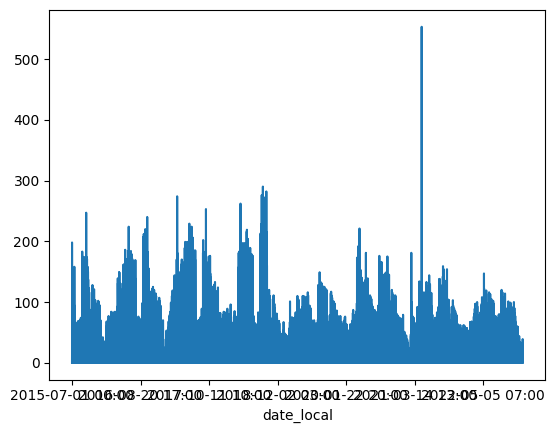

In [21]:
#Graph
#Datum als xAchse festlegen:
bike.set_index("date_local")["bike_lft"].plot() #set_index heißt das "date_local" auf die x achse kommt in verbindung mit der plot methode.
#Ergebnis nicht so gut weil die Zeitspanne so groß ist

In [22]:
#Eine zufällige Woche ansehen
bike
#dafür Datum in Jahr, Tag und Uhrzeit aufteilen und neue Spalten dafür erstellen
bike["date_local"].dt.year() #mit dt kann ich auf date-time Attribute zugreifen. Aber hier gibt es noch ein Fehler weil es noch kein Datetime Objekt ist!

AttributeError: Can only use .dt accessor with datetimelike values

In [55]:
bike.dtypes # dtypes zeigt die Datentypen der Spalten an
#Bei date_local steht object und das heißt das es wahrscheinlich ein String ist.

date_local    object
bike_lft       int64
bike_total     int64
dtype: object

In [78]:
#Will Date Local in ein Daytime Objekt umwandeln
pd.to_datetime(bike["date_local"]) #die methode to_datetime() wandelt Strings in Datetime Objekte um.

0       2015-07-01 00:00:00
1       2015-07-01 01:00:00
2       2015-07-01 02:00:00
3       2015-07-01 03:00:00
4       2015-07-01 04:00:00
                ...        
65772   2022-12-31 19:00:00
65773   2022-12-31 20:00:00
65774   2022-12-31 21:00:00
65775   2022-12-31 22:00:00
65776   2022-12-31 23:00:00
Name: date_local, Length: 65777, dtype: datetime64[ns]

In [79]:
bike["date_local"] = pd.to_datetime(bike["date_local"]) #ich weise der Spalte jz Datetime Objekte statt Strings zu.

In [81]:
bike.dtypes #hier nochmal typ checken & ich sehe es ist ein datetime Objekt :-)

date_local    datetime64[ns]
bike_lft               int64
bike_total             int64
dtype: object

In [82]:
bike["date_local"].dt.year #an bike ruf  date_local Spalte auf und dann dt.year um das Jahr anzuzeigen. Für jedes Datum gibt es jetzt das Jahr aus.

0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
65772    2022
65773    2022
65774    2022
65775    2022
65776    2022
Name: date_local, Length: 65777, dtype: int32

In [83]:
bike["year"] = bike["date_local"].dt.year #hiermit eine Spalte erstellt die ich year nenne

In [84]:
bike

,date_local,bike_lft,bike_total,year
0,2015-07-01 00:00:00,0,0,2015
1,2015-07-01 01:00:00,2,2,2015
2,2015-07-01 02:00:00,0,0,2015
3,2015-07-01 03:00:00,0,0,2015
4,2015-07-01 04:00:00,8,8,2015
...,...,...,...,...
65772,2022-12-31 19:00:00,15,15,2022
65773,2022-12-31 20:00:00,3,3,2022
65774,2022-12-31 21:00:00,2,2,2022
65775,2022-12-31 22:00:00,7,7,2022


In [85]:
bike["month"] = bike["date_local"].dt.month

In [86]:
bike

,date_local,bike_lft,bike_total,year,month
0,2015-07-01 00:00:00,0,0,2015,7
1,2015-07-01 01:00:00,2,2,2015,7
2,2015-07-01 02:00:00,0,0,2015,7
3,2015-07-01 03:00:00,0,0,2015,7
4,2015-07-01 04:00:00,8,8,2015,7
...,...,...,...,...,...
65772,2022-12-31 19:00:00,15,15,2022,12
65773,2022-12-31 20:00:00,3,3,2022,12
65774,2022-12-31 21:00:00,2,2,2022,12
65775,2022-12-31 22:00:00,7,7,2022,12


In [92]:
bike["week"] = bike["date_local"].dt.isocalendar().week

In [93]:
bike

,date_local,bike_lft,bike_total,year,month,week
0,2015-07-01 00:00:00,0,0,2015,7,27
1,2015-07-01 01:00:00,2,2,2015,7,27
2,2015-07-01 02:00:00,0,0,2015,7,27
3,2015-07-01 03:00:00,0,0,2015,7,27
4,2015-07-01 04:00:00,8,8,2015,7,27
...,...,...,...,...,...,...
65772,2022-12-31 19:00:00,15,15,2022,12,52
65773,2022-12-31 20:00:00,3,3,2022,12,52
65774,2022-12-31 21:00:00,2,2,2022,12,52
65775,2022-12-31 22:00:00,7,7,2022,12,52


In [94]:
eine_woche = bike[(bike["year"]==2015) & (bike["week"]==30)] #filtern

In [95]:
eine_woche.shape

(168, 6)

<Axes: xlabel='date_local'>

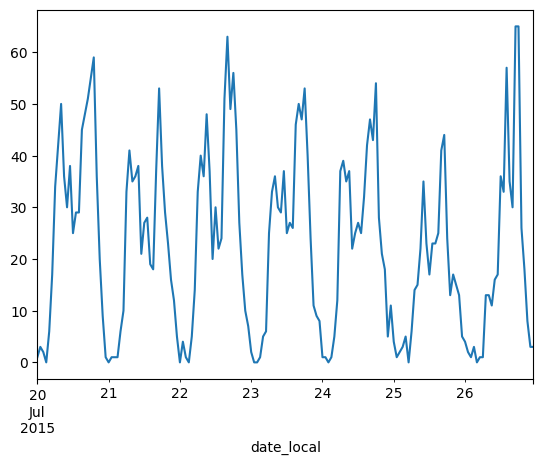

In [98]:
eine_woche.set_index("date_local")["bike_lft"].plot()